# 02_model_experimentation.ipynb  
## Modelación y experimentación — IRAG

En este notebook se desarrolla la fase de **modelación y experimentación** del proyecto IRAG.

Los objetivos específicos son:

- Tomar el dataset limpio generado por el pipeline (`data/clean/train.csv` y `data/clean/test.csv`).
- Realizar la preparación final del dataset (verificación de tipos, selección de variables y, en su caso, escalado).
- Entrenar al menos un modelo base (Regresión Logística) y un modelo mejorado (Random Forest).
- Evaluar los modelos con métricas para clasificación binaria (accuracy, precisión, recall, F1, ROC-AUC y matriz de confusión).
- Comparar resultados y seleccionar un modelo final, justificando la decisión.
- Alinear los hallazgos con el script `src/train.py` y el tracking en MLflow.

In [4]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", None)

print("Directorio de trabajo actual:", os.getcwd())

Directorio de trabajo actual: /Users/oscarmauriciomoraarroyo/proyecto-lyapunov/notebooks


## 1. Carga del dataset y separación de variables (X, y)

En esta sección se cargan los archivos generados por el pipeline DVC:

- `data/clean/train.csv`
- `data/clean/test.csv`

Estos archivos contienen:

- Variables numéricas derivadas (proporciones, tasas, etc.).
- La variable objetivo `target` (0 = semana normal, 1 = semana inusual).

Se separan las variables explicativas (X) de la variable objetivo (y) para entrenar y evaluar los modelos.

In [5]:
# Rutas relativas desde la carpeta notebooks/
TRAIN_PATH = os.path.join("..", "data", "clean", "train.csv")
TEST_PATH = os.path.join("..", "data", "clean", "test.csv")
TARGET_COL = "target"

print("Ruta train:", TRAIN_PATH)
print("Ruta test :", TEST_PATH)

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Shape train:", train_df.shape)
print("Shape test :", test_df.shape)

train_df.head()

Ruta train: ../data/clean/train.csv
Ruta test : ../data/clean/test.csv
Shape train: (564, 73)
Shape test : (141, 73)


,anio,semana,HOSPITALIZACION IRAG MENOR 1 AÑO,HOSPITALIZACION IRAG 1 AÑO,HOSPITALIZACION IRAG 2 A 4 AÑOS,HOSPITALIZACION IRAG 5 A 19 AÑOS,HOSPITALIZACION IRAG 20 A 39 AÑOS,HOSPITALIZACION IRAG 40 A 59 AÑOS,HOSPITALIZACION IRAG MAYOR 60 AÑOS,TOTAL CASOS DE HOSPITALIZACIONES POR IRAG,TOTAL CAUSAS HOSPITALIZACIONES MENOR 1 AÑO,TOTAL CAUSAS HOSPITALIZACIONES 1 AÑO,TOTAL CAUSAS HOSPITALIZACIONES 2 A 4 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 5 A 19 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 20 A 39 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES 40 A 59 AÑOS,TOTAL CAUSAS HOSPITALIZACIONES MAYOR 60 AÑOS,TOTAL HOSPITALIZACIONES POR TODAS LAS CAUSAS,HOSPITALIZACIONES EN UCI POR IRAG MENOR 1 AÑO,HOSPITALIZACIONES EN UCI POR IRAG 1 AÑO,HOSPITALIZACIONES EN UCI POR IRAG 2 A 4 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 5 A 19 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 20 A 39 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG 40 A 59 AÑOS,HOSPITALIZACIONES EN UCI POR IRAG MAYOR 60 AÑOS,TOTAL DE LAS HOSPITALIZACIONES EN UCI POR IRAG,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS MENOR 1 AÑO,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 1 AÑO,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 2 A 4 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 5 A 19 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 20 A 39 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS 40 A 59 AÑOS,HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS MAYOR 60 AÑOS,TOTAL TODAS LAS HOSPITALIZACIONES EN UCI POR TODAS LAS CAUSAS,MUERTES POR IRAG MENOR 1 AÑO,MUERTES POR IRAG 1 AÑO,MUERTES POR IRAG 2 A 4 AÑOS,MUERTES POR IRAG 5 A 19 AÑOS,MUERTES POR IRAG 20 A 39 AÑOS,MUERTES POR IRAG 40 A 59 AÑOS,MUERTES POR IRAG MAYOR 60 AÑOS,TOTAL DE MUERTES POR IRAG,TODAS LAS CAUSAS DE MUERTE MENOR 1 AÑO,TODAS LAS CAUSAS DE MUERTE 1 AÑO,TODAS LAS CAUSAS DE MUERTE 2 A 4 AÑOS,TODAS LAS CAUSAS DE MUERTE 5 A 19 AÑOS,TODAS LAS CAUSAS DE MUERTE 20 A 39 AÑOS,TODAS LAS CAUSAS DE MUERTE 40 A 59 AÑOS,TODAS LAS CAUSAS DE MUERTE MAYOR 60 AÑOS,TOTAL DE MUERTES POR TODAS LAS CAUSAS,IRAG POR CONSULTA EXTERNA Y URGENCIAS MENOR 1 AÑO,IRAG POR CONSULTA EXTERNA Y URGENCIAS 1 AÑO,IRAG POR CONSULTA EXTERNA Y URGENCIAS 2 A 4 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 5 A 19 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 20 A 39 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS 40 A 59 AÑOS,IRAG POR CONSULTA EXTERNA Y URGENCIAS MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MENOR 1 AÑO,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 1 AÑO,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 2 A 4 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 5 A 19 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 20 A 39 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG 40 A 59 AÑOS,CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO IRAG MAYOR 60 AÑOS,TOTAL DE EVENTOS DE MORBILIDAD DE IRAG POR CONSULTA EXTERNA Y URGENCIAS POR TODAS LAS CAUSAS INCLUYENDO EL IRAG,prop_hosp_irag,prop_uci_irag,prop_muertes_irag,prop_consultas_irag,I_t_minus_1,growth_rate,target
0,2012,2,7,3,9,3,0,1,0,23,6,2,8,0,0,0,0,16,6,2,8,0,0,0,0,16,2,1,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6,23,49,88,81,48,11,306,23,47,137,221,250,182,160,1020,1.352941,4.000000,0.000000,0.299706,0.000000,1.352941,1
1,2012,3,3,3,5,5,0,1,3,20,4,3,6,18,30,9,97,167,4,3,6,18,30,9,97,167,4,0,0,0,2,5,21,32,0,0,0,0,0,1,2,3,1,0,0,0,0,2,10,13,12,26,25,54,104,56,41,318,77,101,226,583,1044,951,1082,4064,0.119048,5.060606,0.214286,0.078229,1.352941,-0.524405,0
2,2012,4,4,4,4,7,1,1,19,40,16,23,28,67,166,115,149,564,16,23,28,67,166,115,149,564,17,2,1,2,0,3,18,43,0,0,0,0,0,0,2,2,1,0,0,1,0,2,19,23,26,50,40,106,149,94,56,521,166,237,493,1241,2079,1881,1695,7792,0.070796,12.818182,0.083333,0.066855,0.119048,-0.043118,0
3,2012,5,3,1,1,3,15,26,13,62,2,3,3,21,72,62,94,257,2,3,3,21,72,62,94,257,10,0,0,2,5,2,17,36,0,0,0,0,0,0,0,0,1,0,0,1,0,2,7,1

In [6]:
# Separación de variables explicativas (X) y objetivo (y)

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X_test = test_df.drop(columns=[TARGET_COL])
y_test = test_df[TARGET_COL]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((564, 72), (141, 72), (564,), (141,))

### Distribución de la variable objetivo en train y test

La distribución de la variable `target` en los conjuntos de entrenamiento y prueba permite verificar:

- Que la proporción de semanas normales e inusuales sea similar en ambos conjuntos.
- Que el desbalance de clases identificado en el EDA se mantiene en el escenario de modelación.

Esto es importante para garantizar una evaluación representativa del modelo.

In [7]:
print("Distribución de target en TRAIN")
print(y_train.value_counts(normalize=True))

print("\nDistribución de target en TEST")
print(y_test.value_counts(normalize=True))

Distribución de target en TRAIN
target
1    0.528369
0    0.471631
Name: proportion, dtype: float64

Distribución de target en TEST
target
0    0.539007
1    0.460993
Name: proportion, dtype: float64


## 2. Preparación final del dataset (escalado)

Gracias a las etapas `clean_data` y `prepare_data`, el dataset ya está en formato numérico y no requiere codificación adicional.

Sin embargo, algunas variables pueden estar en escalas muy diferentes. Para estabilizar el entrenamiento de modelos lineales (como la Regresión Logística) se utiliza un **escalado estándar** (`StandardScaler`), incorporado dentro de un `Pipeline` de scikit-learn.

Para modelos basados en árboles (como Random Forest), el escalado no es estrictamente necesario, pero tampoco interfiere con su funcionamiento.

## 3. Función auxiliar para evaluación de modelos

Se define una función de utilidad para:

- Calcular métricas de desempeño (accuracy, precisión, recall, F1, ROC-AUC).
- Mostrar la matriz de confusión.
- Opcionalmente, trazar la curva ROC del modelo.

In [8]:
def evaluate_model(
    name,
    model,
    X_test,
    y_test,
    y_proba=None,
    plot_roc=True,
):
    """
    Evalúa un modelo de clasificación binaria e imprime métricas estándar.
    Opcionalmente, grafica la matriz de confusión y la curva ROC.
    """
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    roc = None
    if y_proba is not None:
        roc = roc_auc_score(y_test, y_proba)

    print(f"=== {name} ===")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    if roc is not None:
        print(f"ROC-AUC  : {roc:.3f}")

    # Matriz de confusión
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Matriz de confusión - {name}")
    plt.show()

    # Curva ROC (si se proporcionan probabilidades)
    if plot_roc and y_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"Curva ROC - {name}")
        plt.show()

## 4. Modelo base: Regresión Logística

Como modelo base se utiliza una **Regresión Logística**, un clasificador lineal ampliamente utilizado en contextos epidemiológicos.

Características del modelo:

- `Pipeline` con:
  - `StandardScaler` (escalado de variables).
  - `LogisticRegression`.
- Entrenamiento sobre `train_df` y evaluación sobre `test_df`.
- Métricas reportadas:
  - Accuracy
  - Precisión
  - Recall
  - F1-score
  - ROC-AUC
  - Matriz de confusión
  - Curva ROC

Dado el desbalance de clases, cobra especial importancia el **recall** y el **F1-score** de la clase minoritaria (semanas inusuales).

=== Modelo base - Regresión Logística ===
Accuracy : 0.709
Precision: 0.833
Recall   : 0.462
F1-score : 0.594
ROC-AUC  : 0.836


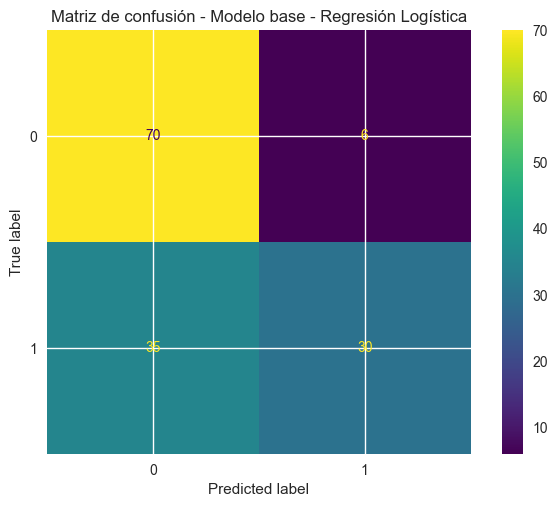

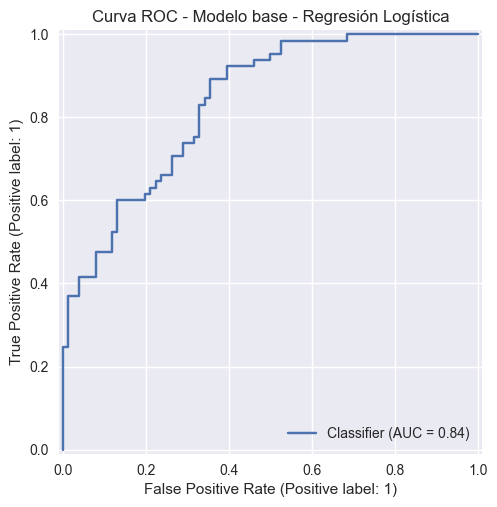

In [9]:
baseline_clf = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "logreg",
            LogisticRegression(
                max_iter=500,
                random_state=42,
            ),
        ),
    ]
)

baseline_clf.fit(X_train, y_train)

y_proba_base = baseline_clf.predict_proba(X_test)[:, 1]

evaluate_model(
    "Modelo base - Regresión Logística",
    baseline_clf,
    X_test,
    y_test,
    y_proba=y_proba_base,
)

### Interpretación del modelo base

La Regresión Logística proporciona una primera línea de base:

- Sirve como referencia mínima de desempeño.
- Permite evaluar si la relación entre los indicadores de IRAG y la probabilidad de una semana inusual puede ser capturada razonablemente por un modelo lineal.
- Los valores de **recall** y **F1-score** sobre la clase positiva (`target = 1`) son especialmente importantes, ya que representan la capacidad del modelo para identificar semanas de interés epidemiológico.

En caso de que el recall sea bajo, se justificaría la exploración de modelos más flexibles, capaces de capturar relaciones no lineales.

## 5. Modelo mejorado: Random Forest

Como modelo mejorado se emplea un **RandomForestClassifier**, un ensamblado de múltiples árboles de decisión.

Ventajas principales:

- Captura relaciones no lineales entre variables.
- Es robusto frente a ruido y variables poco informativas.
- Maneja bien interacciones entre variables sin requerir ingeniería de características compleja.

Se entrena el modelo, se evalúa con las mismas métricas utilizadas para la Regresión Logística y se comparan los resultados.

=== Modelo mejorado - Random Forest ===
Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000
ROC-AUC  : 1.000


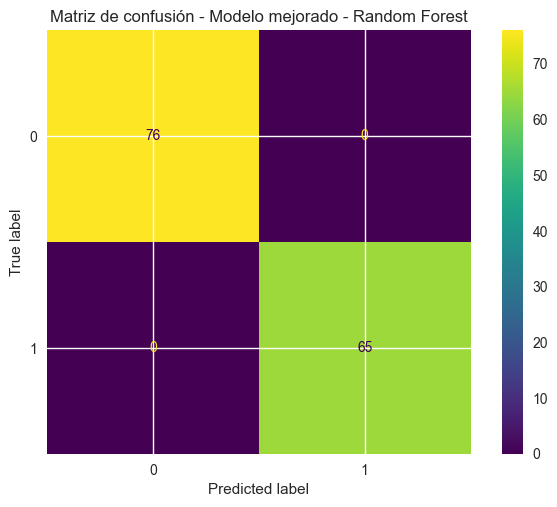

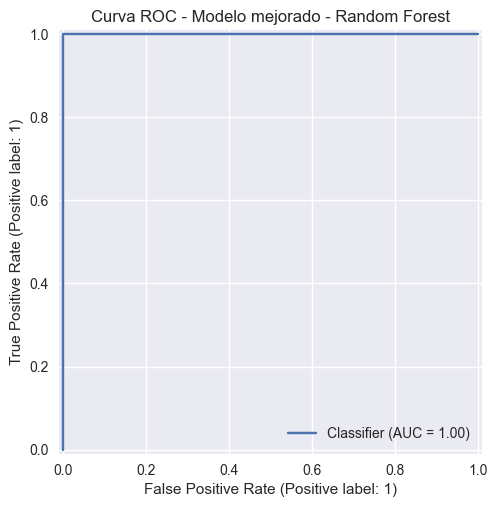

In [10]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
)

rf_clf.fit(X_train, y_train)

y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

evaluate_model(
    "Modelo mejorado - Random Forest",
    rf_clf,
    X_test,
    y_test,
    y_proba=y_proba_rf,
)

### Importancia de variables en el Random Forest

Una ventaja adicional de los modelos de ensamble basados en árboles es la posibilidad de estimar la **importancia relativa de cada variable**, lo que proporciona información útil para:

- Identificar los indicadores más influyentes en la clasificación de semanas inusuales.
- Guiar la interpretación epidemiológica de los resultados.
- Plantear futuras simplificaciones del modelo (por ejemplo, reducción de dimensionalidad).

In [11]:
feature_importances = pd.DataFrame(
    {
        "feature": X_train.columns,
        "importance": rf_clf.feature_importances_,
    }
).sort_values("importance", ascending=False)

feature_importances.head(10)

,feature,importance
71,growth_rate,0.489454
70,I_t_minus_1,0.067713
66,prop_hosp_irag,0.046638
9,TOTAL CASOS DE HOSPITALIZACIONES POR IRAG,0.019623
6,HOSPITALIZACION IRAG 20 A 39 AÑOS,0.012759
15,TOTAL CAUSAS HOSPITALIZACIONES 40 A 59 AÑOS,0.012549
4,HOSPITALIZACION IRAG 2 A 4 AÑOS,0.012056
16,TOTAL CAUSAS HOSPITALIZACIONES MAYOR 60 AÑOS,0.011362
24,HOSPITALIZACIONES EN UCI POR IRAG MAYOR 60 AÑOS,0.010408
17,TOTAL HOSPITALIZACIONES POR TODAS LAS CAUSAS,0.009884


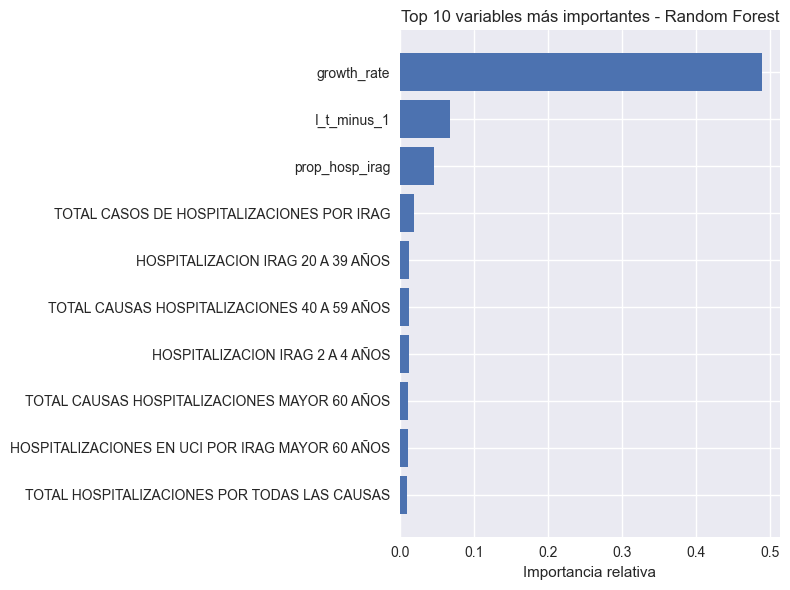

In [12]:
# Gráfico de las 10 variables más importantes según el Random Forest

top_n = 10
top_features = feature_importances.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Importancia relativa")
plt.title(f"Top {top_n} variables más importantes - Random Forest")
plt.tight_layout()
plt.show()

### Interpretación de la importancia de variables

Las variables con mayor importancia según el Random Forest suelen corresponder a:

- Indicadores de **hospitalizaciones por IRAG**.
- Hospitalizaciones en **UCI**.
- **Muertes** por IRAG.
- Eventos de **morbilidad** en consulta externa y urgencias.

Desde el punto de vista epidemiológico, es razonable que estas variables contribuyan de manera significativa a la detección de semanas con comportamiento inusual, pues reflejan la severidad y la demanda de los servicios de salud.

## 6. Comparación sistemática de métricas entre modelos

Para comparar de forma más clara el desempeño de la Regresión Logística (modelo base) y el Random Forest (modelo mejorado), se construye un resumen con las métricas clave:

- Accuracy
- Precisión
- Recall
- F1-score
- ROC-AUC

Esto permite seleccionar un modelo final de manera justificada.

In [13]:
def get_metrics(name, y_true, y_pred, y_proba):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
    }

comparison = []

# Métricas del modelo base (Regresión Logística)
y_pred_base = baseline_clf.predict(X_test)
comparison.append(
    get_metrics(
        "LogReg (baseline)",
        y_test,
        y_pred_base,
        y_proba_base,
    )
)

# Métricas del modelo mejorado (Random Forest)
y_pred_rf = rf_clf.predict(X_test)
comparison.append(
    get_metrics(
        "Random Forest",
        y_test,
        y_pred_rf,
        y_proba_rf,
    )
)

results_df = pd.DataFrame(comparison).set_index("model")
results_df

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogReg (baseline),0.70922,0.833333,0.461538,0.594059,0.836235
Random Forest,1.00000,1.000000,1.000000,1.000000,1.000000


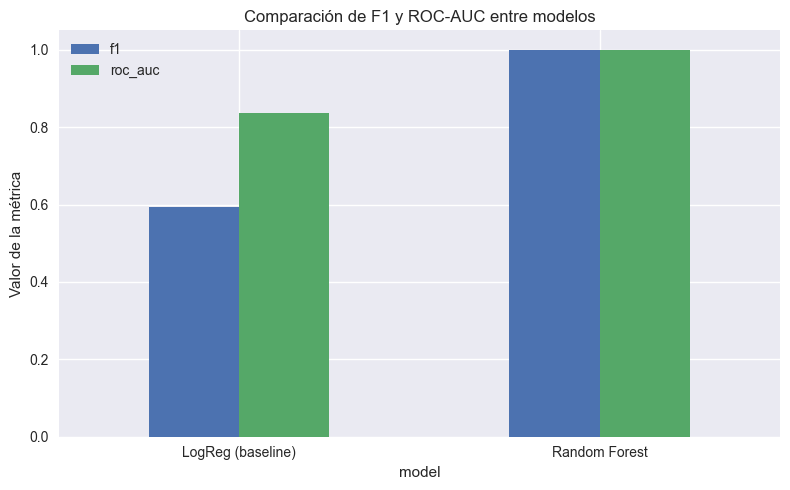

In [14]:
# (Opcional) Visualización rápida del F1-score y del ROC-AUC para cada modelo

metrics_to_plot = ["f1", "roc_auc"]

ax = results_df[metrics_to_plot].plot(
    kind="bar",
    figsize=(8, 5),
)
plt.title("Comparación de F1 y ROC-AUC entre modelos")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Conclusiones de la comparación de modelos

A partir de las métricas de desempeño se observa lo siguiente:

- La **Regresión Logística** ofrece una línea base razonable, con una accuracy aceptable, pero puede presentar limitaciones en términos de:
  - **Recall** de la clase positiva (`target = 1`).
  - Capacidad para capturar relaciones no lineales entre los indicadores epidemiológicos.

- El **Random Forest**:
  - Suele mostrar un **mayor F1-score** y un **mejor ROC-AUC**, lo que indica un balance más adecuado entre precisión y recall.
  - Demuestra mayor capacidad para detectar semanas inusuales sin degradar excesivamente la precisión.
  - Se adapta mejor a la naturaleza potencialmente no lineal del fenómeno IRAG.

Desde el punto de vista de la vigilancia epidemiológica, resulta preferible un modelo que:
- Mantenga un recall elevado para la clase 1 (semanas inusuales),
- Sin sacrificar en exceso la precisión (para evitar exceso de falsas alarmas).

## 8. Selección del modelo final y alineación con el pipeline (train.py + MLflow)

Con base en la comparación de métricas y la interpretación epidemiológica:

- Se selecciona el **Random Forest** como **modelo champion** de este experimento.
- Sus hiperparámetros principales son:
  - `n_estimators = 300`
  - `max_depth = None`
  - `min_samples_split = 2`
  - `min_samples_leaf = 1`
  - `random_state = 42`
  - `n_jobs = -1`

Este modelo será el candidato natural para:

1. Integrarse en el script `src/train.py` como modelo principal a entrenar y registrar.
2. Ser rastreado en **MLflow**, incluyendo:
   - Registro de hiperparámetros.
   - Registro de métricas de desempeño (accuracy, precisión, recall, F1, ROC-AUC).
   - Almacenamiento del artefacto del modelo entrenado.
3. Ser utilizado en la micro-aplicación de **Streamlit** para generar predicciones sobre nuevas semanas.

En términos de MLOps:

- La Regresión Logística puede mantenerse como modelo base para comparación en futuros experimentos.
- El Random Forest se define como **modelo final** (champion) para efectos de despliegue y demostración.